# 05 - Final Model Evaluation

This notebook evaluates the tuned fraud detection models on the held-out test set.

Reasoning: the test set must be treated as the final exam. Preprocessing, hyperparameter search, and threshold tuning already happened before this notebook. Here we only measure final behavior, explain the tradeoffs, and save evaluation artifacts for model selection.

## 1. Setup

Reasoning: fraud detection is an extreme class imbalance problem, so the notebook reports threshold-dependent metrics such as precision, recall, F1, F2, false positives, and false negatives, plus threshold-independent ranking metrics such as ROC-AUC and average precision.

In [1]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'processed'
REPORTS_PATH = PROJECT_ROOT / 'reports'
MODELS_PATH = PROJECT_ROOT / 'models'
PLOTS_PATH = PROJECT_ROOT / 'plots'

REPORTS_PATH.mkdir(exist_ok=True)
MODELS_PATH.mkdir(exist_ok=True)
PLOTS_PATH.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml


## 2. Load Test Data, Tuned Models, and Thresholds

Reasoning: the evaluation must use the same preprocessed test set created in the preprocessing notebook. The tuned thresholds come from validation data, not the test set, which keeps the evaluation honest.

In [2]:
required_files = {
    'X_test': DATA_PATH / 'X_test_scaled.csv',
    'y_test': DATA_PATH / 'y_test.csv',
    'tuning_results': REPORTS_PATH / 'tuning_results.csv',
    'tuned_thresholds': REPORTS_PATH / 'tuned_thresholds.csv',
}

missing = [str(path.relative_to(PROJECT_ROOT)) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Missing required files. Run notebooks/02_preprocessing.ipynb and notebooks/04_model_tuning.ipynb first: '
        + ', '.join(missing)
    )

X_test = pd.read_csv(required_files['X_test'])
y_test = pd.read_csv(required_files['y_test']).squeeze('columns').astype(int)
tuning_results = pd.read_csv(required_files['tuning_results'])
thresholds = pd.read_csv(required_files['tuned_thresholds']).set_index('Model')['Threshold'].to_dict()

models = {}
for _, row in tuning_results.iterrows():
    model_name = row['Model']
    model_path = PROJECT_ROOT / str(row['Saved Model']).replace('\\', '/')
    if not model_path.exists():
        raise FileNotFoundError(f'Missing saved model for {model_name}: {model_path}')
    with open(model_path, 'rb') as f:
        models[model_name] = pickle.load(f)

print(f'Test shape: {X_test.shape}')
print(f'Test fraud cases: {int(y_test.sum())} / {len(y_test)} ({y_test.mean():.4%})')
print(f'Loaded models: {list(models)}')
display(tuning_results)

Test shape: (56746, 30)
Test fraud cases: 95 / 56746 (0.1674%)
Loaded models: ['XGBoost', 'CatBoost', 'Random Forest', 'Logistic Regression']


,Model,Best Params,CV Average Precision,Validation Threshold,Validation Precision,Validation Recall,Validation F1,Validation F2,Test Precision @0.50,Test Recall @0.50,...,Test F1 @Tuned,Test F2 @Tuned,Test ROC-AUC,Test Average Precision,Test FP @Tuned,Test FN @Tuned,Test TP @Tuned,Train ROC-AUC,Overfit Gap,Saved Model
0,XGBoost,"{'subsample': 0.7, 'scale_pos_weight': 899.214...",0.823776,0.898964,0.955882,0.855263,0.902778,0.873656,0.950000,0.800000,...,0.870588,0.813187,0.968261,0.811376,1,21,74,1.000000,0.031739,models\tuned_xgboost.pkl
1,CatBoost,"{'subsample': 0.9, 'scale_pos_weight': 299.738...",0.825194,0.929327,0.928571,0.855263,0.890411,0.868984,0.926829,0.800000,...,0.858824,0.802198,0.975731,0.813826,2,22,73,0.999991,0.024260,models\tuned_catboost.pkl
2,Random Forest,"{'n_estimators': 250, 'min_samples_split': 5, ...",0.794041,0.363446,0.866667,0.855263,0.860927,0.857520,0.943662,0.705263,...,0.843931,0.796943,0.943814,0.810184,5,22,73,0.999973,0.056159,models\tuned_random_forest.pkl
3,Logistic Regression,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.001}",0.513606,0.906203,0.206081,0.802632,0.327957,0.508333,0.031808,0.863158,...,0.356808,0.534459,0.961543,0.502620,255,19,76,0.979795,0.018253,models\tuned_logistic_regression.pkl


## 3. Metric Functions

Reasoning: accuracy is avoided as a headline metric because a model that predicts every transaction as normal would still look accurate. F2 is included because missing fraud is usually more costly than investigating a small number of false alarms.

In [3]:
def predict_scores(model, X):
    if hasattr(model, 'get_params') and 'n_jobs' in model.get_params():
        model.set_params(n_jobs=1)
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        raw_scores = model.decision_function(X)
        return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    raise TypeError('Model must expose predict_proba or decision_function.')


def fbeta_score_from_precision_recall(precision, recall, beta=2):
    return ((1 + beta**2) * precision * recall) / ((beta**2 * precision) + recall + 1e-12)


def evaluate_at_threshold(model_name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score_from_precision_recall(precision, recall, beta=2)
    specificity = tn / (tn + fp) if (tn + fp) else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) else 0
    false_negative_rate = fn / (fn + tp) if (fn + tp) else 0
    review_rate = (tp + fp) / len(y_true)
    return {
        'Model': model_name,
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'F2': f2,
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Average Precision': average_precision_score(y_true, y_proba),
        'Specificity': specificity,
        'False Positive Rate': false_positive_rate,
        'False Negative Rate': false_negative_rate,
        'Review Rate': review_rate,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
    }

## 4. Evaluate Tuned Models on the Test Set

Reasoning: each tuned model is evaluated at its validation-selected threshold. This answers the practical question: if we deploy the model with the threshold chosen before seeing the test set, how many fraud cases do we catch and how many normal transactions do we flag?

In [4]:
probabilities = {}
evaluation_rows = []
default_threshold_rows = []

for model_name, model in models.items():
    y_proba = predict_scores(model, X_test)
    probabilities[model_name] = y_proba
    tuned_threshold = float(thresholds[model_name])
    evaluation_rows.append(evaluate_at_threshold(model_name, y_test, y_proba, tuned_threshold))
    default_threshold_rows.append(evaluate_at_threshold(model_name, y_test, y_proba, 0.50))

evaluation_df = pd.DataFrame(evaluation_rows)
default_threshold_df = pd.DataFrame(default_threshold_rows)

extra_cols = tuning_results[['Model', 'CV Average Precision', 'Validation Precision', 'Validation Recall', 'Validation F2', 'Train ROC-AUC', 'Overfit Gap']]
evaluation_df = evaluation_df.merge(extra_cols, on='Model', how='left')
evaluation_df = evaluation_df.sort_values(['F2', 'Average Precision', 'ROC-AUC'], ascending=False).reset_index(drop=True)

evaluation_path = REPORTS_PATH / 'final_evaluation_results.csv'
default_path = REPORTS_PATH / 'default_threshold_evaluation.csv'
evaluation_df.to_csv(evaluation_path, index=False)
default_threshold_df.to_csv(default_path, index=False)

display(Markdown('### Tuned Threshold Evaluation'))
display(evaluation_df)
display(Markdown('### Default 0.50 Threshold Check'))
display(default_threshold_df)
print(f'Saved: {evaluation_path}')
print(f'Saved: {default_path}')

### Tuned Threshold Evaluation

,Model,Threshold,Precision,Recall,F1,F2,ROC-AUC,Average Precision,Specificity,False Positive Rate,...,TN,FP,FN,TP,CV Average Precision,Validation Precision,Validation Recall,Validation F2,Train ROC-AUC,Overfit Gap
0,XGBoost,0.898964,0.986667,0.778947,0.870588,0.813187,0.968261,0.811376,0.999982,0.000018,...,56650,1,21,74,0.823776,0.955882,0.855263,0.873656,1.000000,0.031739
1,CatBoost,0.929327,0.973333,0.768421,0.858824,0.802198,0.975731,0.813826,0.999965,0.000035,...,56649,2,22,73,0.825194,0.928571,0.855263,0.868984,0.999991,0.024260
2,Random Forest,0.363446,0.935897,0.768421,0.843931,0.796943,0.943814,0.810184,0.999912,0.000088,...,56646,5,22,73,0.794041,0.866667,0.855263,0.857520,0.999973,0.056159
3,Logistic Regression,0.906203,0.229607,0.800000,0.356808,0.534459,0.961543,0.502620,0.995499,0.004501,...,56396,255,19,76,0.513606,0.206081,0.802632,0.508333,0.979795,0.018253


### Default 0.50 Threshold Check

,Model,Threshold,Precision,Recall,F1,F2,ROC-AUC,Average Precision,Specificity,False Positive Rate,False Negative Rate,Review Rate,TN,FP,FN,TP
0,XGBoost,0.5,0.950000,0.800000,0.868571,0.826087,0.968261,0.811376,0.999929,0.000071,0.200000,0.001410,56647,4,19,76
1,CatBoost,0.5,0.926829,0.800000,0.858757,0.822511,0.975731,0.813826,0.999894,0.000106,0.200000,0.001445,56645,6,19,76
2,Random Forest,0.5,0.943662,0.705263,0.807229,0.742794,0.943814,0.810184,0.999929,0.000071,0.294737,0.001251,56647,4,28,67
3,Logistic Regression,0.5,0.031808,0.863158,0.061354,0.138607,0.961543,0.502620,0.955941,0.044059,0.136842,0.045431,54155,2496,13,82


Saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\reports\final_evaluation_results.csv
Saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\reports\default_threshold_evaluation.csv


## 5. Confusion Matrices

Reasoning: precision, recall, and F-scores are useful, but fraud projects need raw counts too. A false negative is a missed fraud case. A false positive is a normal transaction sent for review.

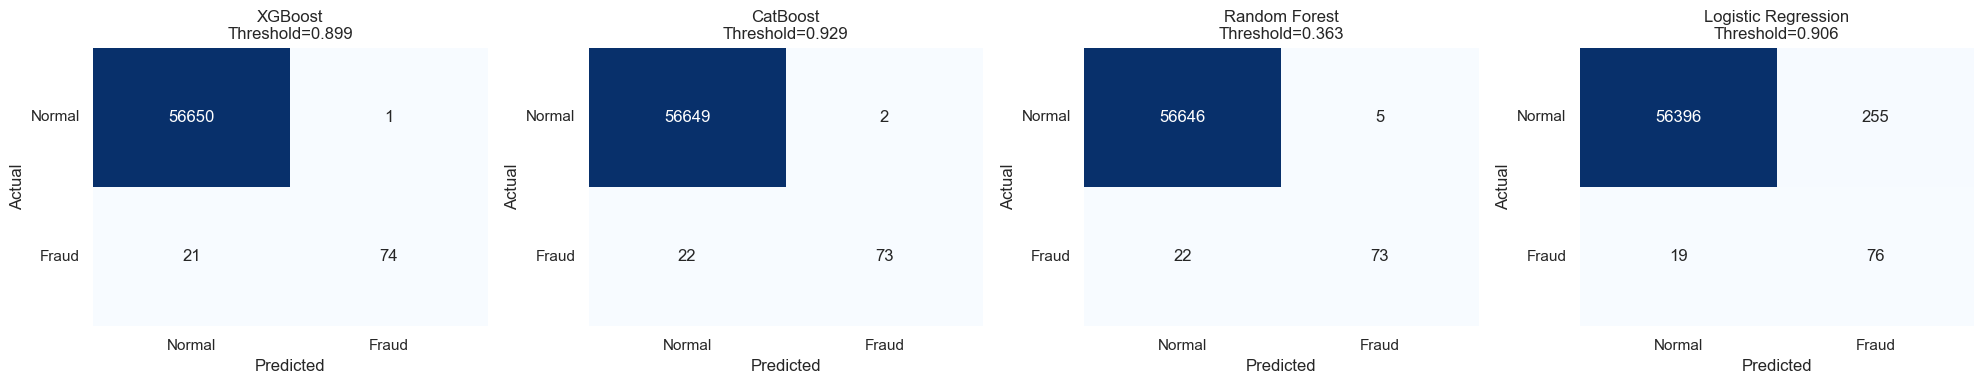

Saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\plots\06_final_confusion_matrices.png


In [5]:
n_models = len(evaluation_df)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, evaluation_df.iterrows()):
    model_name = row['Model']
    cm = np.array([[row['TN'], row['FP']], [row['FN'], row['TP']]], dtype=int)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{model_name}\nThreshold={row["Threshold"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Normal', 'Fraud'])
    ax.set_yticklabels(['Normal', 'Fraud'], rotation=0)

plt.tight_layout()
cm_path = PLOTS_PATH / '06_final_confusion_matrices.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

## 6. ROC and Precision-Recall Curves

Reasoning: ROC-AUC shows ranking quality over all thresholds, but precision-recall curves are more informative when the positive class is tiny. Average precision is therefore a key evaluation number here.

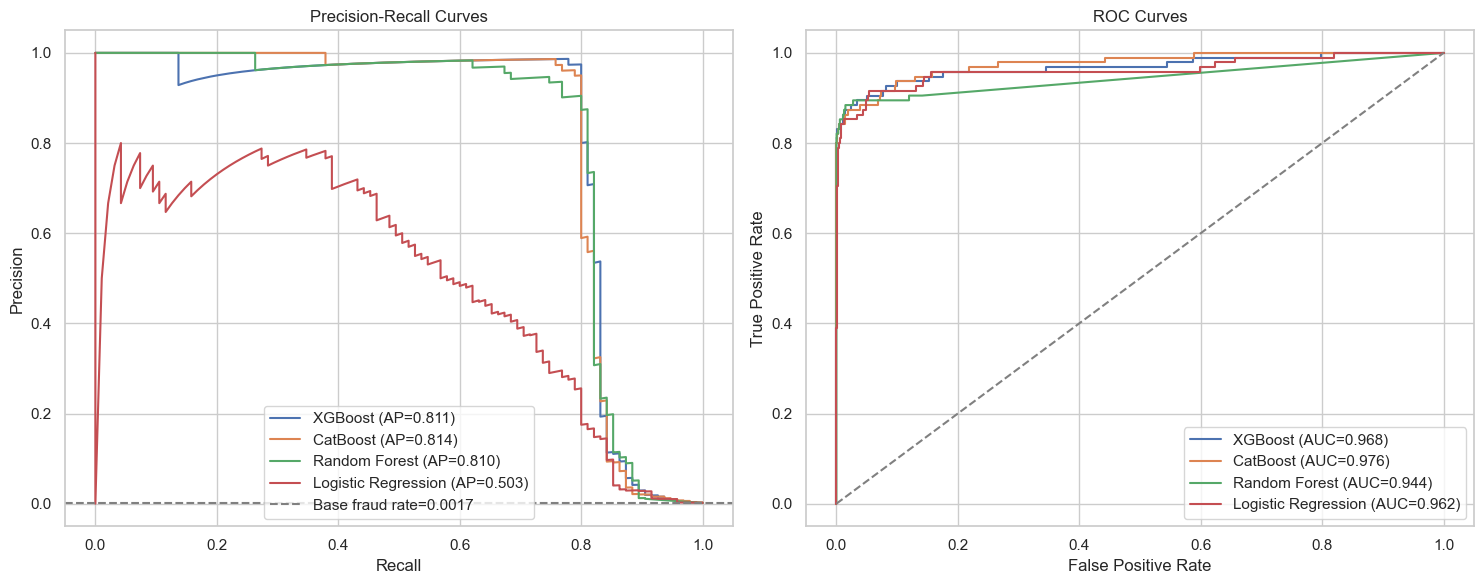

Saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\plots\07_final_pr_roc_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for _, row in evaluation_df.iterrows():
    model_name = row['Model']
    y_proba = probabilities[model_name]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    axes[0].plot(recall, precision, label=f'{model_name} (AP={row["Average Precision"]:.3f})')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{model_name} (AUC={row["ROC-AUC"]:.3f})')

base_rate = y_test.mean()
axes[0].axhline(base_rate, color='gray', linestyle='--', label=f'Base fraud rate={base_rate:.4f}')
axes[0].set_title('Precision-Recall Curves')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()

axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
curve_path = PLOTS_PATH / '07_final_pr_roc_curves.png'
plt.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {curve_path}')

## 7. Threshold Sensitivity

Reasoning: model quality and decision threshold are different decisions. This section shows how precision, recall, and F2 change if the business wants to catch more fraud or reduce review workload.

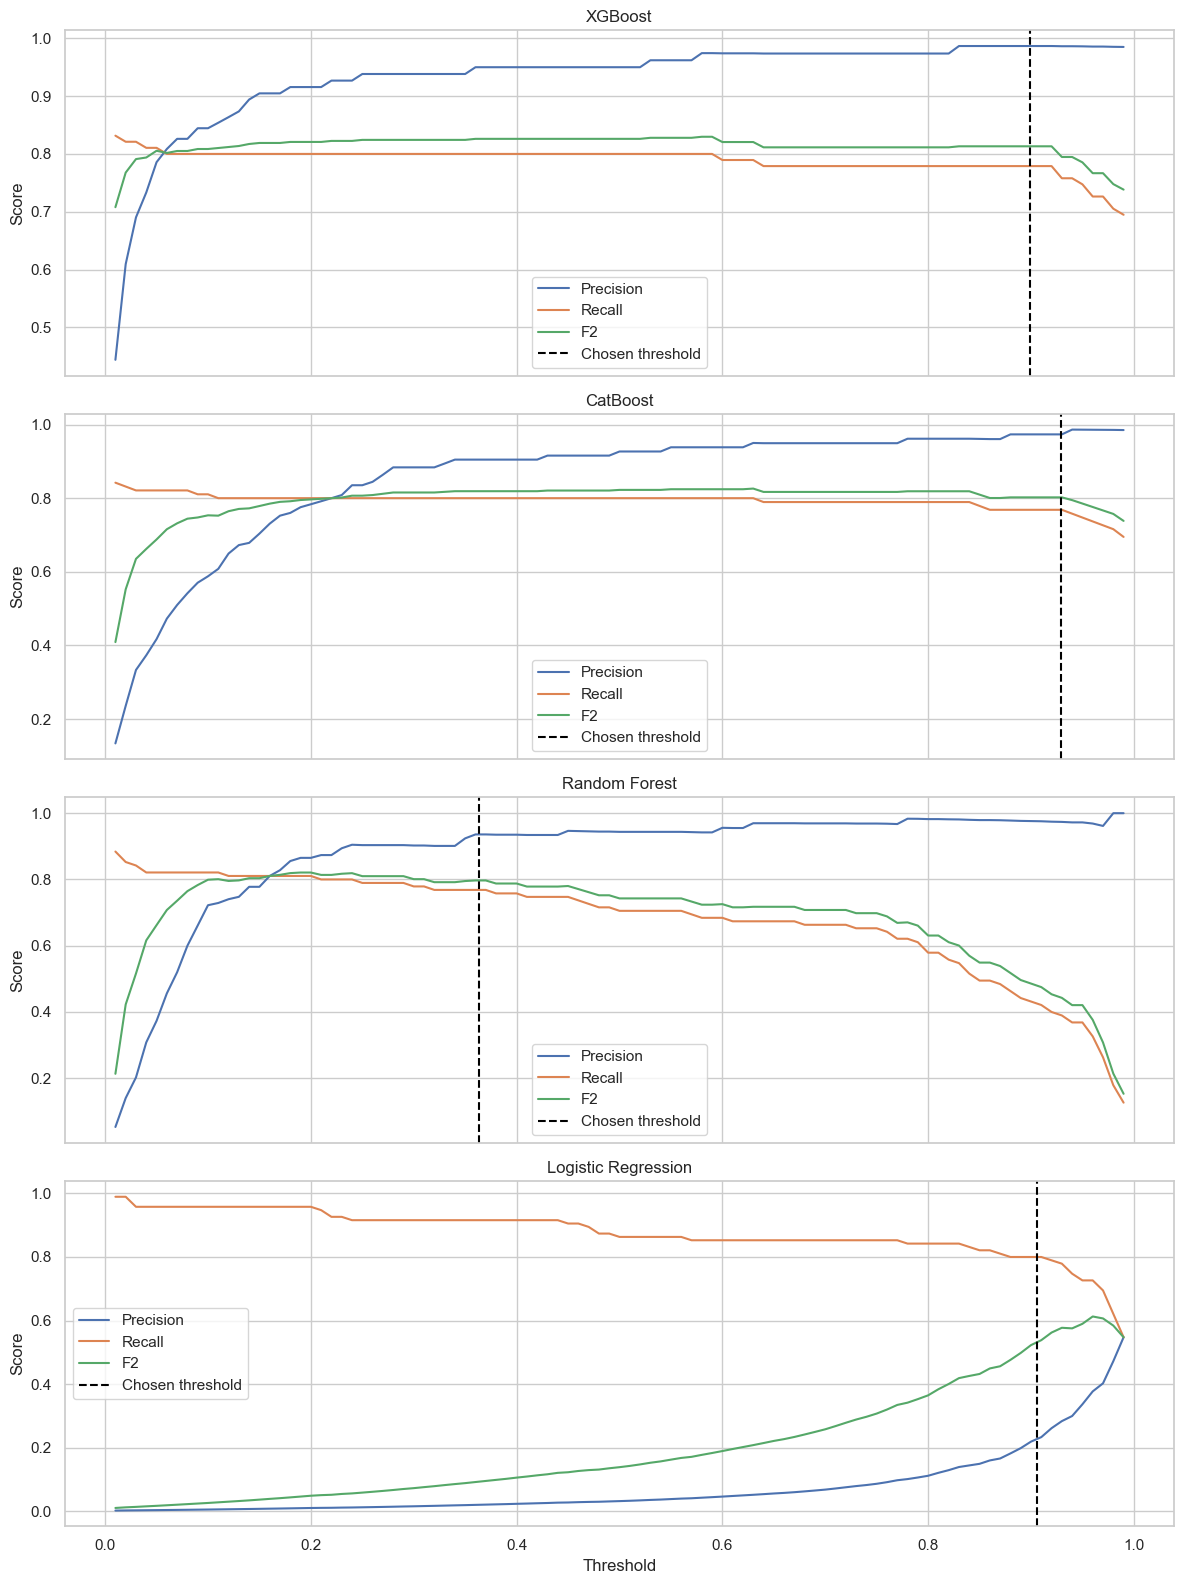

Saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\reports\threshold_sensitivity.csv
Saved: d:\NU\Spring 2026\ML\credit_card_fraud_detection_ml\plots\08_threshold_sensitivity.png


In [7]:
threshold_grid = np.linspace(0.01, 0.99, 99)
sensitivity_rows = []

for model_name, y_proba in probabilities.items():
    for threshold in threshold_grid:
        sensitivity_rows.append(evaluate_at_threshold(model_name, y_test, y_proba, float(threshold)))

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_path = REPORTS_PATH / 'threshold_sensitivity.csv'
sensitivity_df.to_csv(sensitivity_path, index=False)

fig, axes = plt.subplots(len(models), 1, figsize=(12, 4 * len(models)), sharex=True)
if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, evaluation_df['Model']):
    model_df = sensitivity_df[sensitivity_df['Model'] == model_name]
    ax.plot(model_df['Threshold'], model_df['Precision'], label='Precision')
    ax.plot(model_df['Threshold'], model_df['Recall'], label='Recall')
    ax.plot(model_df['Threshold'], model_df['F2'], label='F2')
    ax.axvline(thresholds[model_name], color='black', linestyle='--', label='Chosen threshold')
    ax.set_title(model_name)
    ax.set_ylabel('Score')
    ax.legend()

axes[-1].set_xlabel('Threshold')
plt.tight_layout()
threshold_plot_path = PLOTS_PATH / '08_threshold_sensitivity.png'
plt.savefig(threshold_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {sensitivity_path}')
print(f'Saved: {threshold_plot_path}')

## 8. Evaluation Summary Report

Reasoning: this report translates the table into project language. It does not select the final model yet; it identifies the strongest candidates and the tradeoffs that model selection must resolve.

In [8]:
best_f2 = evaluation_df.sort_values('F2', ascending=False).iloc[0]
best_ap = evaluation_df.sort_values('Average Precision', ascending=False).iloc[0]
best_recall = evaluation_df.sort_values('Recall', ascending=False).iloc[0]
best_precision = evaluation_df.sort_values('Precision', ascending=False).iloc[0]

summary_lines = [
    '=' * 80,
    'FINAL MODEL EVALUATION REPORT',
    '=' * 80,
    '',
    '1. EVALUATION RULES',
    '   - The held-out test set is used only here, after tuning and threshold selection.',
    '   - Accuracy is not used as a headline metric because fraud is less than 1% of the data.',
    '   - Precision, recall, F1, F2, ROC-AUC, average precision, FP, and FN are reported.',
    '   - F2 is included because missing fraud is usually more expensive than reviewing a small number of false alarms.',
    '',
    '2. BEST MODELS BY EVALUATION VIEW',
    f"   - Best F2 balance: {best_f2['Model']} (F2={best_f2['F2']:.4f}, Precision={best_f2['Precision']:.4f}, Recall={best_f2['Recall']:.4f})",
    f"   - Best average precision: {best_ap['Model']} (AP={best_ap['Average Precision']:.4f}, ROC-AUC={best_ap['ROC-AUC']:.4f})",
    f"   - Highest recall: {best_recall['Model']} (Recall={best_recall['Recall']:.4f}, FN={int(best_recall['FN'])})",
    f"   - Highest precision: {best_precision['Model']} (Precision={best_precision['Precision']:.4f}, FP={int(best_precision['FP'])})",
    '',
    '3. MODEL TRADEOFFS',
]

for _, row in evaluation_df.iterrows():
    summary_lines.extend([
        f"   - {row['Model']}:",
        f"     threshold={row['Threshold']:.5f}, precision={row['Precision']:.4f}, recall={row['Recall']:.4f}, F2={row['F2']:.4f}, AP={row['Average Precision']:.4f}",
        f"     catches {int(row['TP'])} fraud cases, misses {int(row['FN'])}, and creates {int(row['FP'])} false positives.",
    ])

summary_lines.extend([
    '',
    '4. FILES CREATED',
    '   - reports/final_evaluation_results.csv',
    '   - reports/default_threshold_evaluation.csv',
    '   - reports/threshold_sensitivity.csv',
    '   - reports/final_evaluation_summary.txt',
    '   - plots/06_final_confusion_matrices.png',
    '   - plots/07_final_pr_roc_curves.png',
    '   - plots/08_threshold_sensitivity.png',
    '',
    '5. NEXT STEP',
    '   - Use notebooks/06_model_selection.ipynb to turn these evaluation tradeoffs into a final project decision.',
    '',
    '=' * 80,
])

summary_text = '\n'.join(summary_lines)
summary_path = REPORTS_PATH / 'final_evaluation_summary.txt'
summary_path.write_text(summary_text, encoding='utf-8')
print(summary_text)
print(f'Saved: {summary_path}')

FINAL MODEL EVALUATION REPORT

1. EVALUATION RULES
   - The held-out test set is used only here, after tuning and threshold selection.
   - Accuracy is not used as a headline metric because fraud is less than 1% of the data.
   - Precision, recall, F1, F2, ROC-AUC, average precision, FP, and FN are reported.
   - F2 is included because missing fraud is usually more expensive than reviewing a small number of false alarms.

2. BEST MODELS BY EVALUATION VIEW
   - Best F2 balance: XGBoost (F2=0.8132, Precision=0.9867, Recall=0.7789)
   - Best average precision: CatBoost (AP=0.8138, ROC-AUC=0.9757)
   - Highest recall: Logistic Regression (Recall=0.8000, FN=19)
   - Highest precision: XGBoost (Precision=0.9867, FP=1)

3. MODEL TRADEOFFS
   - XGBoost:
     threshold=0.89896, precision=0.9867, recall=0.7789, F2=0.8132, AP=0.8114
     catches 74 fraud cases, misses 21, and creates 1 false positives.
   - CatBoost:
     threshold=0.92933, precision=0.9733, recall=0.7684, F2=0.8022, AP=0.8138
  